# LJ Pair MD Notebook

Uses the neighbor-list path in `md.py` to run a pairwise Lennard-Jones test with:
1. a padded fixed-width neighbor list
2. periodic boundary conditions
3. a full-configuration pair potential differentiated with `jax.value_and_grad`

In [2]:
import sys
sys.path.insert(0, '.')

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from ase.build import bulk

from md import MD, Timer
from potentials import get_potential
from trajectory_io import view_trajectory_ngl, write_ovito_dump
from plotting import plot_xy, plot_xy_multiple
from neighbor_list import create_fluid_structure

## 3. Run 1

In [3]:
sigma = 1.0
eps = 1.0
r_skin = 0.3 * sigma
temperature = 1.0
density = 0.15
num_atoms = 64
max_neighbors = num_atoms

dt = 0.004
m  = 1.0

key = jax.random.PRNGKey(42)
key_v = key

# r0, box = create_fluid_structure(
#     density=density,
#     num_atoms=num_atoms,
#     seed=42,
#     min_distance=0.5,
# )

a = (4/density)**(1/3)
fcc_lattice_constant = a
fcc_repetitions = (3, 3, 3)

atoms = bulk('Cu', 'fcc', a=fcc_lattice_constant, cubic=True).repeat(fcc_repetitions)
r0 = jnp.array(atoms.get_positions(), dtype=jnp.float32)
box = jnp.array(atoms.cell.lengths(), dtype=jnp.float32)

N = len(r0)
r_cut = 2.5 * sigma
potential = get_potential("lennard_jones", eps=eps, sigma=sigma, r_cut=r_cut, shift=True)
v0 = MD.initialize_velocities(N, temperature=temperature, m=m, rng_key=key_v)
a0 = jnp.zeros((N, 3))

print(f"box: {box}")
print(f"N: {N}")
print(f"temperature: {temperature}")
print(f"r_cut: {r_cut:.3f}, r_skin: {r_skin:.3f}, max_neighbors: {max_neighbors}")
print(f"r0: {r0.shape}, v0: {v0.shape}, a0: {a0.shape}")

sim = MD(
    r0,
    v0,
    a0,
    potential,
    dt=dt,
    m=m,
    neighbor_list_mode="many-body",
    box=box,
    r_cut=r_cut,
    r_skin=r_skin,
    neighbor_list_pbc=True,
    neighbor_list_padded=True,
    neighbor_list_max_neighbors=max_neighbors,
)

with Timer("MD run (progress mode)"):
    traj_1 = sim.run(n_steps=5000, performance=True, chunk_size=20, progress_backend="notebook")

print(f"positions trajectory : {traj_1['positions'].shape}")
print(f"forces trajectory    : {traj_1['forces'].shape}")
print(f"temperature shape    : {traj_1['temperature'].shape}")
print(f"final positions      : {sim.r.shape}")

sim.save_trajectory('trajectory')

loaded_1 = MD.load_trajectory('trajectory.npz')
print({k: v.shape for k, v in loaded_1.items()})

box: [8.96281 8.96281 8.96281]
N: 108
temperature: 1.0
r_cut: 2.500, r_skin: 0.300, max_neighbors: 64
r0: (108, 3), v0: (108, 3), a0: (108, 3)
[MD run (progress mode)] elapsed: 30.2151s
positions trajectory : (5000, 108, 3)
forces trajectory    : (5000, 108, 3)
temperature shape    : (5000,)
final positions      : (108, 3)
Trajectory saved to trajectory.npz
{'positions': (5000, 108, 3), 'unwrapped_positions': (5000, 108, 3), 'velocities': (5000, 108, 3), 'accelerations': (5000, 108, 3), 'forces': (5000, 108, 3), 'potential_energy': (5000,), 'kinetic_energy': (5000,), 'temperature': (5000,)}


### Run 2

In [4]:
sigma = 1.0
eps = 1.0
r_skin = 0.3 * sigma
temperature = 1.0
density = 0.15
num_atoms = 64
max_neighbors = num_atoms

dt = 0.004
m  = 1.0

key = jax.random.PRNGKey(42)
key_v = key

# r0, box = create_fluid_structure(
#     density=density,
#     num_atoms=num_atoms,
#     seed=42,
#     min_distance=0.5,
# )

a = (4/density)**(1/3)
fcc_lattice_constant = a
fcc_repetitions = (3, 3, 3)

atoms = bulk('Cu', 'fcc', a=fcc_lattice_constant, cubic=True).repeat(fcc_repetitions)
r0 = jnp.array(atoms.get_positions(), dtype=jnp.float32)
box = jnp.array(atoms.cell.lengths(), dtype=jnp.float32)

N = len(r0)
r_cut = 2.5 * sigma
potential = get_potential("lennard_jones", eps=eps, sigma=sigma, r_cut=r_cut, shift=True)
v0_run2 = v0.copy()
v0_run2 = v0_run2.at[0, 0].add(1e-5)
a0 = jnp.zeros((N, 3))

print(f"box: {box}")
print(f"N: {N}")
print(f"temperature: {temperature}")
print(f"r_cut: {r_cut:.3f}, r_skin: {r_skin:.3f}, max_neighbors: {max_neighbors}")
print(f"r0: {r0.shape}, v0: {v0.shape}, a0: {a0.shape}")

sim = MD(
    r0,
    v0_run2,
    a0,
    potential,
    dt=dt,
    m=m,
    neighbor_list_mode="many-body",
    box=box,
    r_cut=r_cut,
    r_skin=r_skin,
    neighbor_list_pbc=True,
    neighbor_list_padded=True,
    neighbor_list_max_neighbors=max_neighbors,
)

with Timer("MD run (progress mode)"):
    traj_2 = sim.run(n_steps=5000, performance=True, chunk_size=20, progress_backend="notebook")

print(f"positions trajectory : {traj_2['positions'].shape}")
print(f"forces trajectory    : {traj_2['forces'].shape}")
print(f"temperature shape    : {traj_2['temperature'].shape}")
print(f"final positions      : {sim.r.shape}")

sim.save_trajectory('trajectory_run2')

loaded_2 = MD.load_trajectory('trajectory_run2.npz')
print({k: v.shape for k, v in loaded_2.items()})

box: [8.96281 8.96281 8.96281]
N: 108
temperature: 1.0
r_cut: 2.500, r_skin: 0.300, max_neighbors: 64
r0: (108, 3), v0: (108, 3), a0: (108, 3)
[MD run (progress mode)] elapsed: 28.6608s
positions trajectory : (5000, 108, 3)
forces trajectory    : (5000, 108, 3)
temperature shape    : (5000,)
final positions      : (108, 3)
Trajectory saved to trajectory_run2.npz
{'positions': (5000, 108, 3), 'unwrapped_positions': (5000, 108, 3), 'velocities': (5000, 108, 3), 'accelerations': (5000, 108, 3), 'forces': (5000, 108, 3), 'potential_energy': (5000,), 'kinetic_energy': (5000,), 'temperature': (5000,)}


## 5. Analysis


### Lyapunov Instability


4.1937248e+06


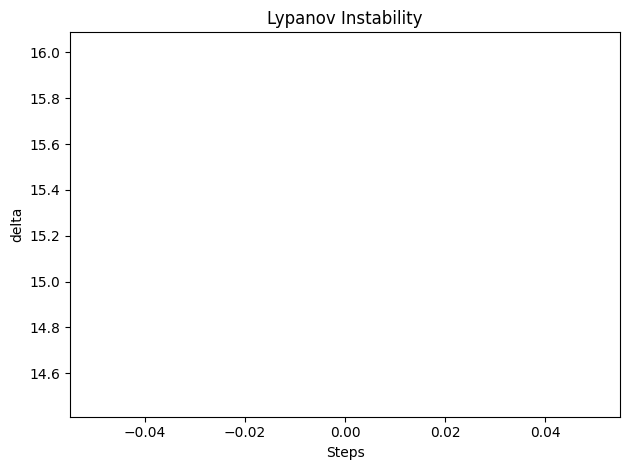

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Lypanov Instability'}, xlabel='Steps', ylabel='delta'>,
 PosixPath('plots/li_lj/lypanov_instability.png'))

In [ ]:
r_traj_1 = traj_1["positions"]
r_traj_2 = traj_2["positions"]

r_1 = np.linalg.norm(r_traj_1, axis=-1)
r_2 = np.linalg.norm(r_traj_2, axis=-1)

delta = np.sum(np.abs(r_1 - r_2)**2,axis=-1)
delta = np.sum((r_traj_1 - r_traj_2) ** 2, axis=(-1, -2))
print(delta)

plot_xy(None, np.log(delta + 1e-10), xlabel="Steps", ylabel="delta", title="Lypanov Instability", name="li_lj",save=True)

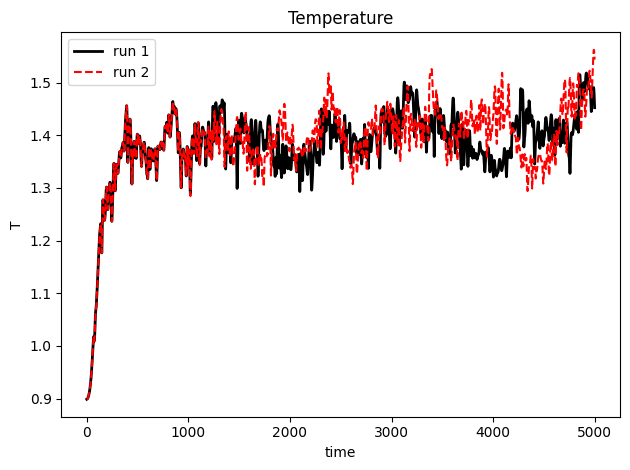

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Temperature'}, xlabel='time', ylabel='T'>,
 PosixPath('plots/li_lj/temperature.png'))

In [10]:
temp_traj_1 = traj_1["temperature"]
temp_traj_2 = traj_2["temperature"]

plot_xy_multiple(
    [
        {"x": None, "y": temp_traj_1, "label": "run 1", "color": "black", "linewidth": 2},
        {"x": None, "y": temp_traj_2, "label": "run 2", "color": "red", "linestyle": "--"},
    ],
    xlabel="time",
    ylabel="T",
    title="Temperature",
    name="li_lj",
    legend=True,
    save=True,
)

In [7]:
r = traj_1["unwrapped_positions"]  
n_steps = len(r)
max_lag = n_steps // 2 

msd_run1 = np.zeros(max_lag)
for delta_t in range(1, max_lag):
    displacements = r[delta_t:] - r[:n_steps - delta_t]  
    squared_disp = np.sum(displacements ** 2, axis=-1)   
    msd_run1[delta_t] = np.mean(squared_disp)                 

In [8]:
r = traj_2["unwrapped_positions"]  
n_steps = len(r)
max_lag = n_steps // 2 

msd_run2 = np.zeros(max_lag)
for delta_t in range(1, max_lag):
    displacements = r[delta_t:] - r[:n_steps - delta_t]  
    squared_disp = np.sum(displacements ** 2, axis=-1)   
    msd_run2[delta_t] = np.mean(squared_disp)                 

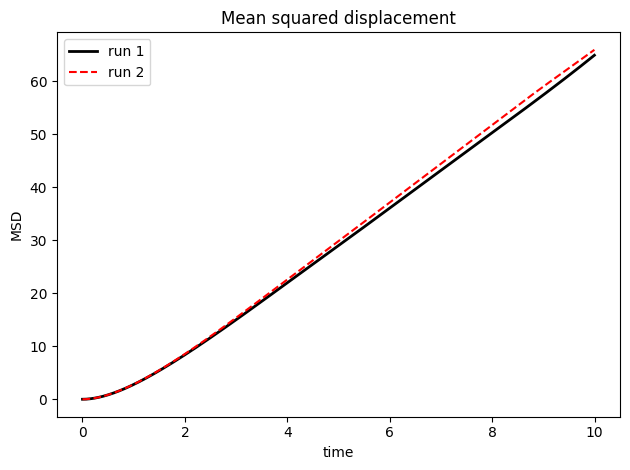

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Mean squared displacement'}, xlabel='time', ylabel='MSD'>,
 PosixPath('plots/li_lj/mean_squared_displacement.png'))

In [9]:
time = np.arange(max_lag) * dt

plot_xy_multiple(
    [
        {"x": time, "y": msd_run1, "label": "run 1", "color": "black", "linewidth": 2},
        {"x": time, "y": msd_run2, "label": "run 2", "color": "red", "linestyle": "--"},
    ],
    xlabel="time",
    ylabel="MSD",
    title="Mean squared displacement",
    name="li_lj",
    legend=True,
    save=True,
)